# Statistical Validation Tests for Effective-Connectivity Methods

Three statistical tests applied to four effective-connectivity methods from `src/methods/fc_pipeline.py`:

| # | Test | Question answered |
|---|------|-------------------|
| 1 | **Bootstrap Performance** | What is the 95 % CI around each method's AUC-ROC across subjects? |
| 2 | **Surrogate Analysis** | Is detected connectivity significantly above the phase-randomized null? |
| 3 | **Time Reversal Test** | Does the method detect *directed* (asymmetric) connectivity? |

Tests are implemented in `src/methods/statistical_tests.py`.  
Data are generated with `src/simulation/simulation_models.py` using the **`random`** model.

**Methods compared:**

| Method | Type | Expected time-reversal asymmetry |
|--------|------|----------------------------------|
| cGC  | Time-domain, directed | High (GC changes under reversal) |
| ADTF | Frequency-domain, directed | High |
| PSI  | Frequency-domain, directed | High |
| PLI  | Frequency-domain, **undirected** | Low (~0, symmetric by construction) |

## 0. Setup

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')


from simulation.simulation_models import simulate
from methods.fc_pipeline import FCMethods
from methods.statistical_tests import (
    bootstrap_all_methods,
    surrogate_test,
    time_reversal_all_methods,
)

sns.set_theme(style='whitegrid', palette='Set2')
print('All imports OK')

All imports OK


## 1. Simulate Data

The **`random`** model (Nolte et al.) generates 5 z-score-normalised channels with known delayed coupling:

```
x1 (pure noise)
x2 = (1-c)*noise + c*x1(t-3)    -> x1 drives x2 with delay 3
x3 = (1-c)*noise + c*x1(t-2)    -> x1 drives x3 with delay 2
x4 (pure noise)
x5 = (1-c)*noise + c*x4(t-5)    -> x4 drives x5 with delay 5
```

We generate:
- **1 single-subject epoch** (seed 0) for the surrogate and time-reversal tests.
- **20 subjects** (seeds 0–19) for the bootstrap test.

In [2]:
# Parameters
FS         = 256     # sampling frequency (Hz)
T          = 1000    # time points per epoch
N_NODES    = 5
N_SUBJECTS = 20
MODEL      = 'random'

# Ground truth adjacency matrix for 'random' model [source, target]
# GT[i, j] = 1  means node i drives node j
ground_truth = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
])

node_labels = [f'x{i+1}' for i in range(N_NODES)]

# Single epoch for surrogate + time-reversal tests
data_example = simulate(model=MODEL, T=T, seed=0)

# Per-subject data for bootstrap test
data_subjects = [simulate(model=MODEL, T=T, seed=s) for s in range(N_SUBJECTS)]

print(f'Model          : {MODEL}')
print(f'Data shape     : {data_example.shape}   (nodes x time)')
print(f'N subjects     : {N_SUBJECTS}')
print(f'True edges     : {list(zip(*np.where(ground_truth)))}  (source, target)')

Model          : random
Data shape     : (5, 1000)   (nodes x time)
N subjects     : 20
True edges     : [(0, 1), (0, 2), (3, 4)]  (source, target)


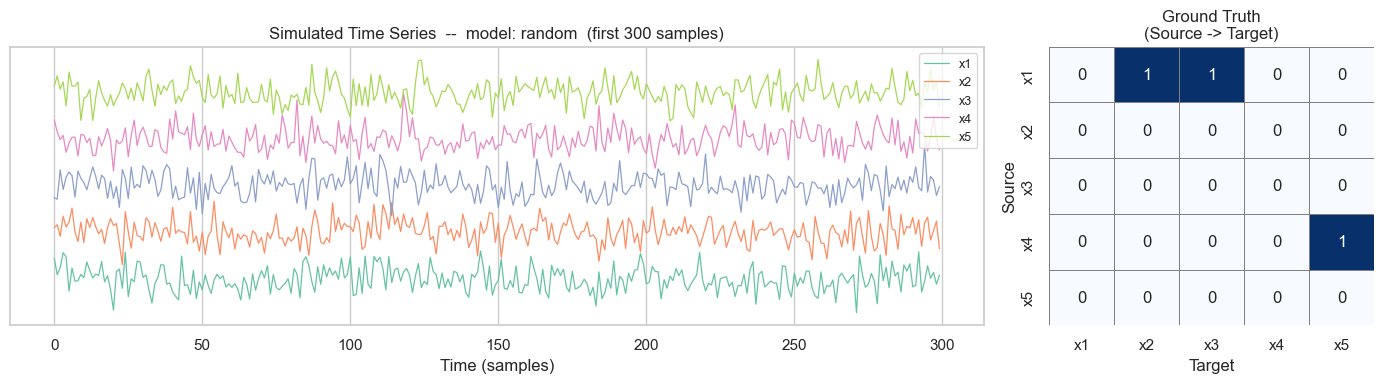

In [3]:
# Visualise time series + ground truth
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={'width_ratios': [3, 1]})

# Time series (offset channels for clarity)
colors = sns.color_palette('Set2', N_NODES)
ax = axes[0]
offset = 0
for i, color in enumerate(colors):
    ax.plot(data_example[i, :300] + offset, color=color, lw=0.9, label=node_labels[i])
    offset += 4
ax.set_xlabel('Time (samples)')
ax.set_title(f'Simulated Time Series  --  model: {MODEL}  (first 300 samples)')
ax.legend(loc='upper right', fontsize=9)
ax.set_yticks([])

# Ground truth heatmap
sns.heatmap(ground_truth, annot=True, fmt='d', cbar=False,
            xticklabels=node_labels, yticklabels=node_labels,
            linewidths=0.5, linecolor='grey', cmap='Blues', ax=axes[1])
axes[1].set_title('Ground Truth\n(Source -> Target)')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Source')

plt.tight_layout()
plt.show()

## 2. Wrap FC Pipeline Methods

Each statistical test in `statistical_tests.py` accepts a callable:
```
fc_func(data: ndarray[n_channels, n_times]) -> matrix: ndarray[n_channels, n_channels]
matrix[i, j] = connectivity from node i to node j   (source -> target)
```

`make_fc_func()` wraps any `FCMethods` method to match this interface.

**Convention note:**  
Non-PSI methods (`cGC`, `ADTF`, `PLI`) return matrices in `[target, source]` order internally → transposed here.  
PSI already returns `[source, target]` → no transpose needed.

In [4]:
def make_fc_func(method_name: str, params: dict, fs: float = FS):
    """
    Wrap a FCMethods method into a simple callable suitable for statistical_tests.py.

    Parameters
    ----------
    method_name : str   — must match a _<name>_func method in FCMethods
    params      : dict  — keyword arguments forwarded to the method
    fs          : float — sampling frequency in Hz

    Returns
    -------
    fc_func : callable
        fc_func(data: ndarray[n_ch, n_t]) -> ndarray[n_ch, n_ch]
        matrix[i, j] = connectivity from i to j  (source -> target)
    """
    is_psi = (method_name == 'PSI')

    def fc_func(data: np.ndarray) -> np.ndarray:
        # FCMethods standardises (n_ch, n_t) to (1, n_ch, n_t) internally,
        # but we add the epoch dim explicitly for clarity.
        fc = FCMethods(data[np.newaxis], fs=fs)
        results = fc.compute_all({method_name: params})
        res = results[method_name]

        if 'error' in res:
            raise RuntimeError(f'{method_name}: {res["error"]}')

        matrix = res['matrix'].copy()
        np.fill_diagonal(matrix, 0)

        # Transpose to [source, target] unless PSI (already correct)
        if not is_psi:
            matrix = matrix.T

        return matrix

    fc_func.__name__ = method_name
    return fc_func


# ── Method definitions ────────────────────────────────────────────────────────
# Use a broad frequency band (1-40 Hz) to capture the delay-based coupling
# present in the 'random' model (broadband white-noise coupling).
FMIN, FMAX = 1, 40

METHOD_PARAMS = {
    'cGC' : {'maxlag': 5, 'mean': True},
    'ADTF': {'fmin': FMIN, 'fmax': FMAX, 'n_freqs': 50, 'maxlags': 5, 'integrate': True},
    'PSI' : {'fmin': FMIN, 'fmax': FMAX, 'integrate': True},
    'PLI' : {'fmin': FMIN, 'fmax': FMAX, 'integrate': True},
}

FC_FUNCS = {
    name: make_fc_func(name, params, fs=FS)
    for name, params in METHOD_PARAMS.items()
}

# ── Sanity check: run each method on the example data ────────────────────────
print(f'{"Method":<10} {"Shape":>10} {"Symmetric":>12} {"Min":>8} {"Max":>8}')
print('-' * 55)
for name, func in FC_FUNCS.items():
    m = func(data_example)
    print(f'{name:<10} {str(m.shape):>10} {str(np.allclose(m, m.T)):>12} '
          f'{m.min():>8.3f} {m.max():>8.3f}')

Method          Shape    Symmetric      Min      Max
-------------------------------------------------------
cGC            (5, 5)        False    0.000    0.792
ADTF           (5, 5)        False    0.000    0.358
PSI            (5, 5)        False   -2.320    2.320
PLI            (5, 5)         True    0.000    1.000


## 3. Bootstrap Performance

**Goal:** Estimate the 95 % confidence interval of each method's AUC-ROC across subjects.

**Procedure:**
1. Compute AUC-ROC for each of the 20 subjects independently.
2. Resample the 20 per-subject AUCs with replacement 1 000 times.
3. Report the 2.5th – 97.5th percentile of the bootstrap mean distribution.

**Key function:** `bootstrap_all_methods(auc_dict, n_iterations=1000, ci=0.95)`

In [5]:
# Per-subject AUC-ROC scores
def compute_auc(fc_matrix: np.ndarray, gt: np.ndarray) -> float:
    """AUC-ROC: |off-diagonal FC values| vs binary ground truth."""
    mask    = ~np.eye(fc_matrix.shape[0], dtype=bool)
    y_true  = gt[mask]
    y_score = np.abs(fc_matrix[mask])
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return np.nan
    return roc_auc_score(y_true, y_score)


print('Computing per-subject AUC scores (20 subjects x 4 methods)...')
auc_dict = {}
for name, func in FC_FUNCS.items():
    print(f'  {name} ...', end=' ', flush=True)
    aucs = [compute_auc(func(d), ground_truth) for d in data_subjects]
    auc_dict[name] = np.array(aucs)
    print(f'mean = {np.nanmean(auc_dict[name]):.3f} +/- {np.nanstd(auc_dict[name]):.3f}')

Computing per-subject AUC scores (20 subjects x 4 methods)...
  cGC ... mean = 1.000 +/- 0.000
  ADTF ... mean = 1.000 +/- 0.000
  PSI ... mean = 0.773 +/- 0.143
  PLI ... mean = 0.500 +/- 0.000


In [6]:
# Bootstrap confidence intervals
boot_results = bootstrap_all_methods(auc_dict, n_iterations=1000, ci=0.95, seed=42)

print(f'\n{"Method":<12} {"Mean":>8} {"CI Lower":>10} {"CI Upper":>10} {"Above chance?":>14}')
print('-' * 58)
for method, res in boot_results.items():
    above = res['ci_lower'] > 0.5
    print(f'{method:<12} {res["mean"]:>8.3f} {res["ci_lower"]:>10.3f} '
          f'{res["ci_upper"]:>10.3f} {str(above):>14}')


Method           Mean   CI Lower   CI Upper  Above chance?
----------------------------------------------------------
cGC             1.000      1.000      1.000           True
ADTF            1.000      1.000      1.000           True
PSI             0.773      0.708      0.832           True
PLI             0.500      0.500      0.500          False


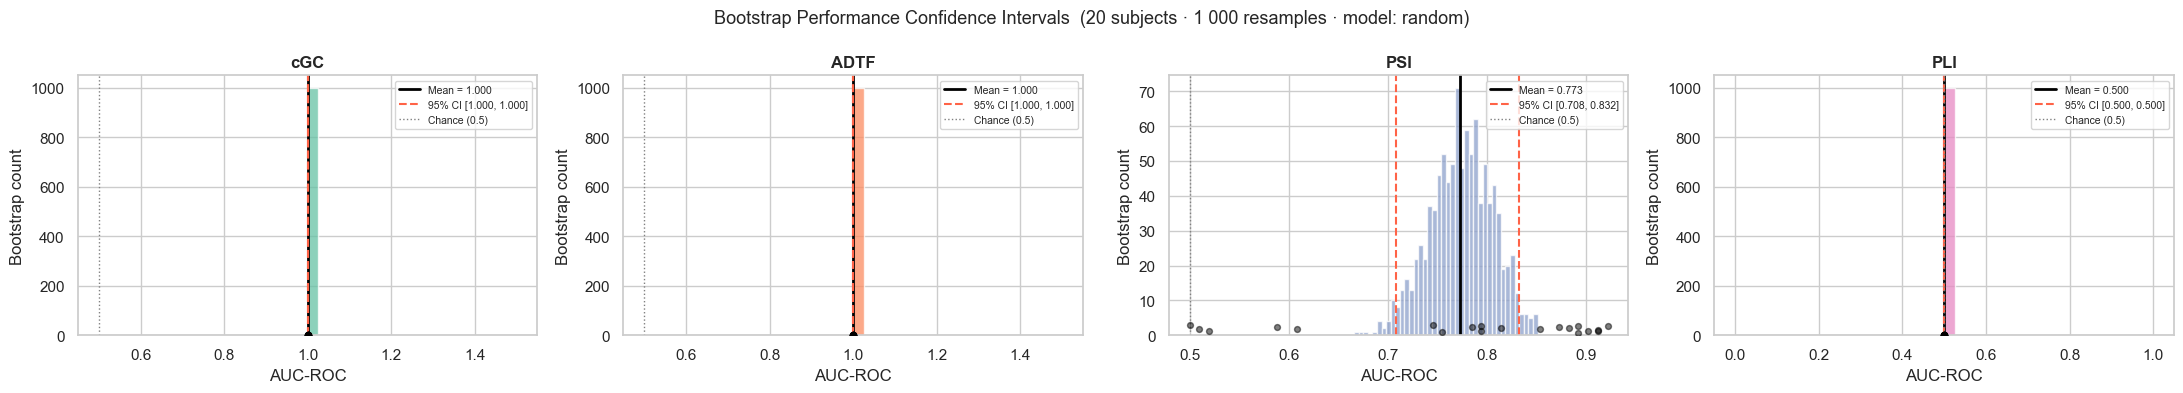

In [7]:
# Visualise bootstrap distributions
n_methods = len(boot_results)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 4), sharey=False)

palette = sns.color_palette('Set2', n_methods)

for ax, (method, res), color in zip(axes, boot_results.items(), palette):
    dist = res['bootstrap_distribution']

    ax.hist(dist, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(res['mean'],     color='k',      lw=2,   linestyle='-',
               label=f'Mean = {res["mean"]:.3f}')
    ax.axvline(res['ci_lower'], color='tomato', lw=1.5, linestyle='--',
               label=f'95% CI [{res["ci_lower"]:.3f}, {res["ci_upper"]:.3f}]')
    ax.axvline(res['ci_upper'], color='tomato', lw=1.5, linestyle='--')
    ax.axvline(0.5,             color='grey',   lw=1,   linestyle=':',
               label='Chance (0.5)')

    # Jittered per-subject dots at the bottom
    rng = np.random.default_rng(7)
    jitter = rng.uniform(0.5, 3, size=len(auc_dict[method]))
    ax.scatter(auc_dict[method], jitter, color='k', alpha=0.5, s=18, zorder=5)

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('AUC-ROC')
    ax.set_ylabel('Bootstrap count')
    ax.legend(fontsize=7.5)

fig.suptitle(
    f'Bootstrap Performance Confidence Intervals  '
    f'({N_SUBJECTS} subjects · 1 000 resamples · model: {MODEL})',
    fontsize=13
)
plt.tight_layout()
plt.show()

## 4. Surrogate Analysis

**Goal:** Test whether each FC method detects connectivity that is significantly above chance.

**Procedure (Prichard & Theiler, 1994):**
1. Compute AUC on the *real* data → `true_score`.
2. Generate `N_SURROGATES` *phase-randomized* surrogates — these preserve the marginal power
   spectrum of each channel while destroying cross-channel phase relationships.
3. Compute AUC on each surrogate → null distribution.
4. Empirical p-value = fraction of surrogates with AUC ≥ `true_score`.

**Key function:** `surrogate_test(data, ground_truth, fc_func, n_surrogates)`  
> `N_SURROGATES = 50` here for speed. Use 200+ for publication-quality results.

In [8]:
# Run surrogate tests (single-epoch example data)
N_SURROGATES = 50   # increase to 200+ for publication

surr_results = {}
for name, func in FC_FUNCS.items():
    print(f'  {name} ({N_SURROGATES} surrogates) ...', end=' ', flush=True)
    res = surrogate_test(
        data         = data_example,
        ground_truth = ground_truth,
        fc_func      = func,
        n_surrogates = N_SURROGATES,
        seed         = 42,
        metric       = 'auc',
    )
    surr_results[name] = res
    sig = 'SIGNIFICANT' if res['p_value'] < 0.05 else 'not significant'
    print(f'p={res["p_value"]:.3f},  z={res["z_score"]:+.2f},  '
          f'true AUC={res["true_score"]:.3f}  [{sig}]')

  cGC (50 surrogates) ... p=1.000,  z=+nan,  true AUC=1.000  [not significant]
  ADTF (50 surrogates) ... p=1.000,  z=+nan,  true AUC=1.000  [not significant]
  PSI (50 surrogates) ... p=0.840,  z=-0.57,  true AUC=0.856  [not significant]
  PLI (50 surrogates) ... p=1.000,  z=+nan,  true AUC=0.614  [not significant]


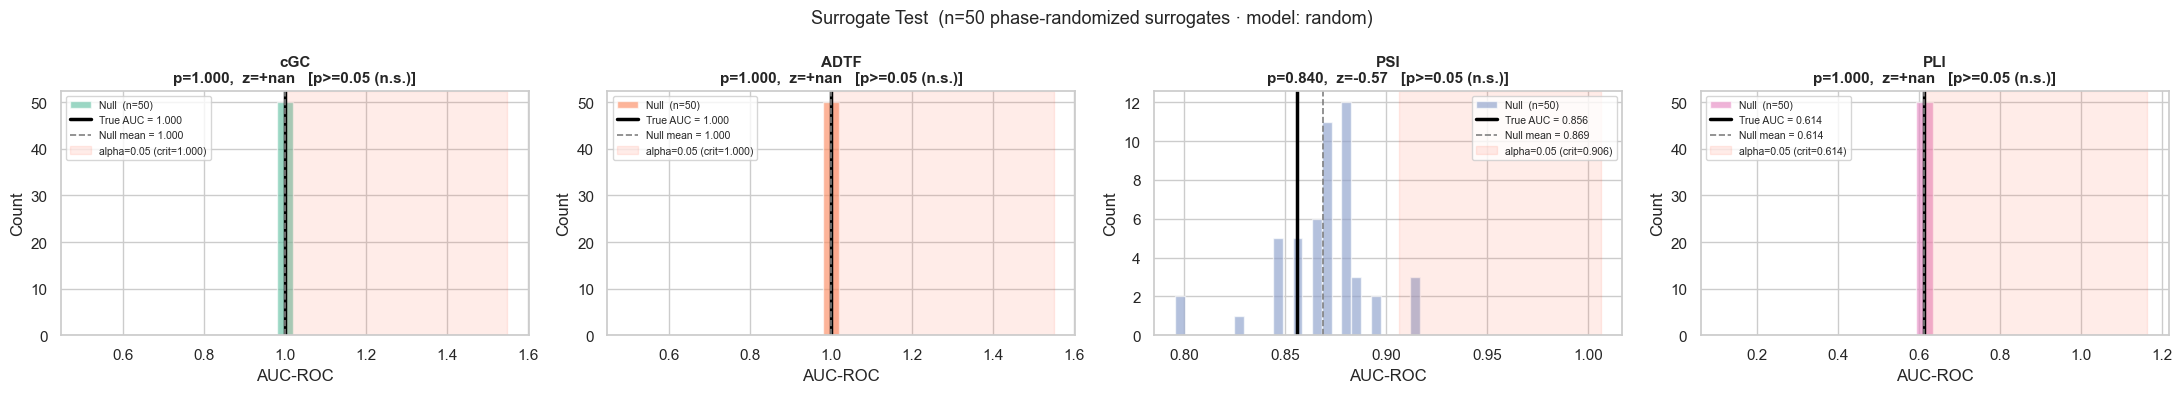

In [9]:
# Visualise surrogate null distributions
n_methods = len(surr_results)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 4), sharey=False)

palette = sns.color_palette('Set2', n_methods)

for ax, (method, res), color in zip(axes, surr_results.items(), palette):
    null     = res['surrogate_scores']
    true_auc = res['true_score']
    p_val    = res['p_value']
    z_val    = res['z_score']
    sig_txt  = 'p<0.05 (sig.)' if p_val < 0.05 else 'p>=0.05 (n.s.)'

    ax.hist(null, bins=25, color=color, alpha=0.65, edgecolor='white',
            label=f'Null  (n={N_SURROGATES})')
    ax.axvline(true_auc,  color='k',    lw=2.5, linestyle='-',
               label=f'True AUC = {true_auc:.3f}')
    ax.axvline(null.mean(), color='grey', lw=1.2, linestyle='--',
               label=f'Null mean = {null.mean():.3f}')

    # Shade one-tailed 5 % rejection region
    crit  = np.percentile(null, 95)
    x_max = max(crit + 0.1, true_auc + 0.05, ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1.0)
    ax.axvspan(crit, x_max, alpha=0.12, color='tomato',
               label=f'alpha=0.05 (crit={crit:.3f})')

    ax.set_title(
        f'{method}\np={p_val:.3f},  z={z_val:+.2f}   [{sig_txt}]',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('AUC-ROC')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7.5)

fig.suptitle(
    f'Surrogate Test  (n={N_SURROGATES} phase-randomized surrogates · model: {MODEL})',
    fontsize=13
)
plt.tight_layout()
plt.show()

## 5. Time Reversal Test

**Goal:** Validate that an FC method is sensitive to the *direction* of information flow.

**Procedure:**
1. Compute FC on original data → `forward_matrix`.
2. Reverse the time axis (`data[:, ::-1]`) and recompute → `reversed_matrix`.
3. Asymmetry index = mean |forward − reversed| over off-diagonal entries.
4. If ground truth provided: compare AUC-ROC forward vs. reversed.

**Expected results:**
- **PLI** (undirected/symmetric): `pli + pli.T` is symmetric by construction → asymmetry index ≈ 0, Δ AUC ≈ 0.
- **cGC / ADTF / PSI** (directed): causal structure changes under time reversal → asymmetry > 0, forward AUC > reversed AUC.

**Key function:** `time_reversal_all_methods(data, fc_funcs, ground_truth)`

In [10]:
# Run time reversal tests
tr_results = time_reversal_all_methods(
    data         = data_example,
    fc_funcs     = FC_FUNCS,
    ground_truth = ground_truth,
    metric       = 'auc',
)

print(f'{"Method":<12} {"Asymmetry":>14} {"Fwd AUC":>10} {"Rev AUC":>10} {"Delta AUC":>12}')
print('-' * 62)
for method, res in tr_results.items():
    print(
        f'{method:<12}'
        f' {res["asymmetry_index"]:>14.4f}'
        f' {res["forward_score"]:>10.3f}'
        f' {res["reversed_score"]:>10.3f}'
        f' {res["score_difference"]:>+12.3f}'
    )

Method            Asymmetry    Fwd AUC    Rev AUC    Delta AUC
--------------------------------------------------------------
cGC                  0.1885      1.000      0.652       +0.348
ADTF                 0.1002      1.000      0.561       +0.439
PSI                  1.9345      0.856      0.864       -0.008
PLI                  0.0000      0.614      0.614       +0.000


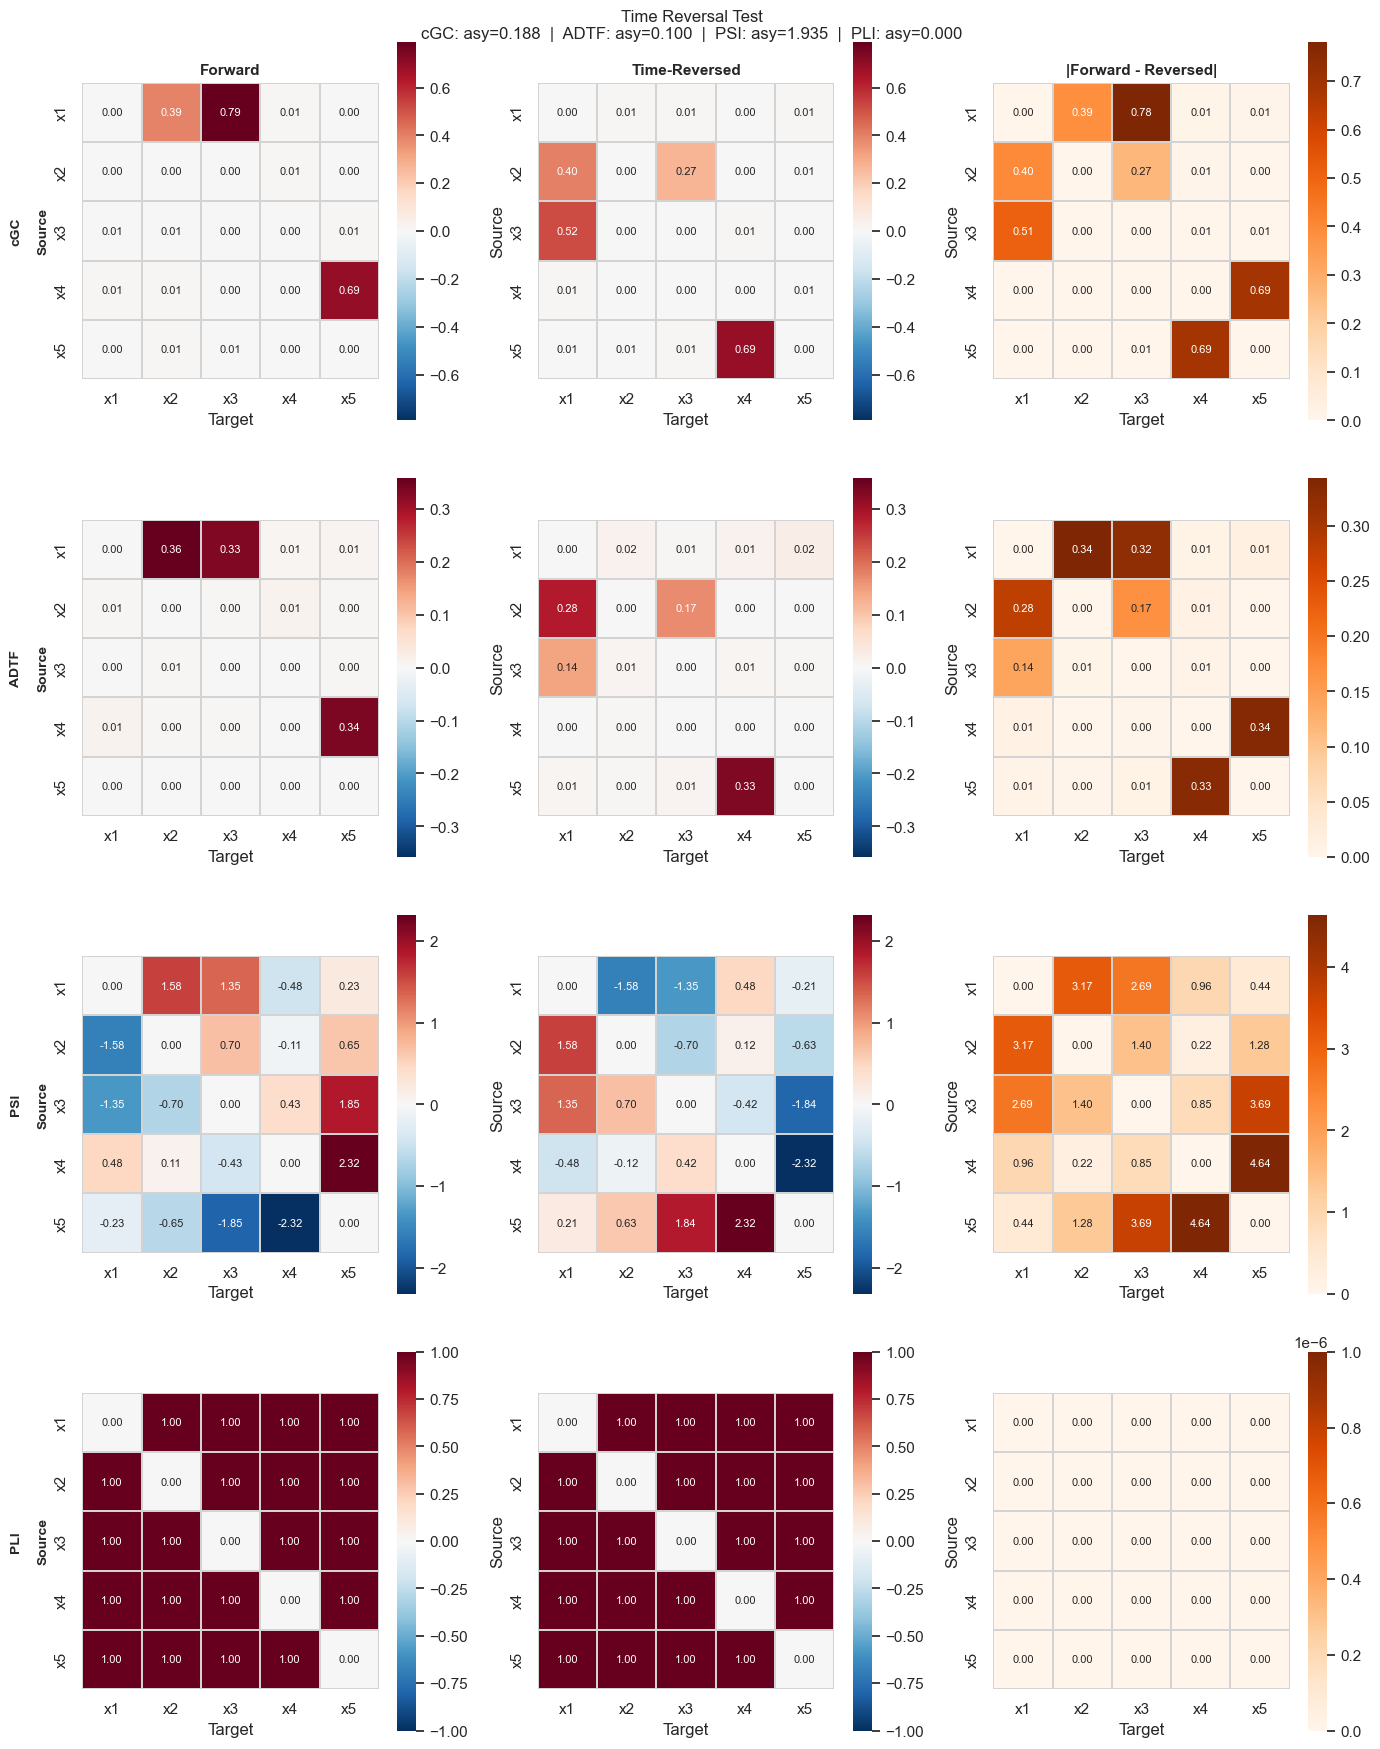

In [11]:
# Heatmaps: Forward | Reversed | |Forward - Reversed|
n_methods  = len(tr_results)
col_titles = ['Forward', 'Time-Reversed', '|Forward - Reversed|']

fig, axes = plt.subplots(n_methods, 3, figsize=(14, 4.5 * n_methods))
if n_methods == 1:
    axes = axes[np.newaxis, :]

for row, (method, res) in enumerate(tr_results.items()):
    fwd_m  = res['forward_matrix'].copy()
    rev_m  = res['reversed_matrix'].copy()
    diff_m = np.abs(fwd_m - rev_m)
    for m in (fwd_m, rev_m, diff_m):
        np.fill_diagonal(m, 0)

    vmax = max(np.abs(fwd_m).max(), np.abs(rev_m).max(), 1e-6)

    for col, (mat, title) in enumerate(zip([fwd_m, rev_m, diff_m], col_titles)):
        ax = axes[row, col]
        if col < 2:
            cmap, vmin_v, vmax_v = 'RdBu_r', -vmax, vmax
        else:
            cmap, vmin_v, vmax_v = 'Oranges', 0, max(diff_m.max(), 1e-6)

        sns.heatmap(
            mat, ax=ax, cmap=cmap, vmin=vmin_v, vmax=vmax_v,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            xticklabels=node_labels, yticklabels=node_labels,
            linewidths=0.3, linecolor='lightgrey'
        )
        if row == 0:
            ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Target')
        ax.set_ylabel('Source')

    axes[row, 0].set_ylabel(f'{method}\n\nSource', fontsize=10, fontweight='bold')

fig.suptitle('Time Reversal Test\n' +
             '  |  '.join(f'{m}: asy={r["asymmetry_index"]:.3f}'
                          for m, r in tr_results.items()),
             fontsize=12)
plt.tight_layout()
plt.show()

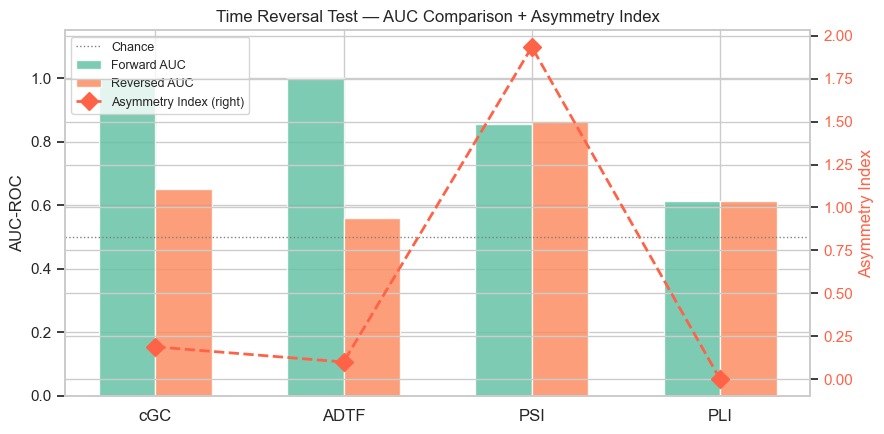

In [12]:
# Bar chart: Forward vs. Reversed AUC + Asymmetry Index
methods_list = list(tr_results.keys())
x     = np.arange(len(methods_list))
width = 0.30

fwd_aucs = [tr_results[m]['forward_score']   for m in methods_list]
rev_aucs = [tr_results[m]['reversed_score']  for m in methods_list]
asym_idx = [tr_results[m]['asymmetry_index'] for m in methods_list]

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()

pal = sns.color_palette('Set2')
ax1.bar(x - width / 2, fwd_aucs, width, label='Forward AUC',
        color=pal[0], alpha=0.85)
ax1.bar(x + width / 2, rev_aucs, width, label='Reversed AUC',
        color=pal[1], alpha=0.85)
ax2.plot(x, asym_idx, 'D--', color='tomato', lw=2, markersize=9,
         label='Asymmetry Index (right)')

ax1.axhline(0.5, color='grey', linestyle=':', lw=1, label='Chance')
ax1.set_xticks(x)
ax1.set_xticklabels(methods_list, fontsize=12)
ax1.set_ylabel('AUC-ROC')
ax1.set_ylim(0, 1.15)
ax2.set_ylabel('Asymmetry Index', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='upper left')
ax1.set_title('Time Reversal Test — AUC Comparison + Asymmetry Index', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Summary

Consolidated results across all three tests and all four effective-connectivity methods.

In [13]:
rows = []
for method in FC_FUNCS:
    b = boot_results[method]
    s = surr_results[method]
    t = tr_results[method]
    rows.append({
        'Method'            : method,
        'Boot. Mean AUC'    : f"{b['mean']:.3f}",
        '95% CI'            : f"[{b['ci_lower']:.3f}, {b['ci_upper']:.3f}]",
        'Surr. p-value'     : f"{s['p_value']:.3f}",
        'Surr. z-score'     : f"{s['z_score']:+.2f}",
        'Significant?'      : 'Yes' if s['p_value'] < 0.05 else 'No',
        'Asymmetry Index'   : f"{t['asymmetry_index']:.4f}",
        'Fwd AUC'           : f"{t['forward_score']:.3f}",
        'Rev AUC'           : f"{t['reversed_score']:.3f}",
        'Delta AUC (F-R)'   : f"{t['score_difference']:+.3f}",
    })

df = pd.DataFrame(rows).set_index('Method')
df

,Boot. Mean AUC,95% CI,Surr. p-value,Surr. z-score,Significant?,Asymmetry Index,Fwd AUC,Rev AUC,Delta AUC (F-R)
Method,,,,,,,,,
cGC,1.000,"[1.000, 1.000]",1.000,+nan,No,0.1885,1.000,0.652,+0.348
ADTF,1.000,"[1.000, 1.000]",1.000,+nan,No,0.1002,1.000,0.561,+0.439
PSI,0.773,"[0.708, 0.832]",0.840,-0.57,No,1.9345,0.856,0.864,-0.008
PLI,0.500,"[0.500, 0.500]",1.000,+nan,No,0.0000,0.614,0.614,+0.000


In [14]:
print('=' * 72)
print('INTERPRETATION SUMMARY')
print('=' * 72)
for method in FC_FUNCS:
    b = boot_results[method]
    s = surr_results[method]
    t = tr_results[method]
    print(f'\n[{method}]')
    print(f'  Bootstrap : mean AUC = {b["mean"]:.3f}, '
          f'95% CI = [{b["ci_lower"]:.3f}, {b["ci_upper"]:.3f}]  '
          f'-> CI above chance: {b["ci_lower"] > 0.5}')
    print(f'  Surrogate : p = {s["p_value"]:.3f}, z = {s["z_score"]:+.2f}  '
          f'-> Significant: {s["p_value"] < 0.05}')
    print(f'  Time Rev  : asymmetry = {t["asymmetry_index"]:.4f}, '
          f'Delta AUC = {t["score_difference"]:+.3f}  '
          f'-> Direction-sensitive: {t["asymmetry_index"] > 0.01}')
print()

INTERPRETATION SUMMARY

[cGC]
  Bootstrap : mean AUC = 1.000, 95% CI = [1.000, 1.000]  -> CI above chance: True
  Surrogate : p = 1.000, z = +nan  -> Significant: False
  Time Rev  : asymmetry = 0.1885, Delta AUC = +0.348  -> Direction-sensitive: True

[ADTF]
  Bootstrap : mean AUC = 1.000, 95% CI = [1.000, 1.000]  -> CI above chance: True
  Surrogate : p = 1.000, z = +nan  -> Significant: False
  Time Rev  : asymmetry = 0.1002, Delta AUC = +0.439  -> Direction-sensitive: True

[PSI]
  Bootstrap : mean AUC = 0.773, 95% CI = [0.708, 0.832]  -> CI above chance: True
  Surrogate : p = 0.840, z = -0.57  -> Significant: False
  Time Rev  : asymmetry = 1.9345, Delta AUC = -0.008  -> Direction-sensitive: True

[PLI]
  Bootstrap : mean AUC = 0.500, 95% CI = [0.500, 0.500]  -> CI above chance: False
  Surrogate : p = 1.000, z = +nan  -> Significant: False
  Time Rev  : asymmetry = 0.0000, Delta AUC = +0.000  -> Direction-sensitive: False

